In [1]:
import numpy as np
import healpy as hp
import pickle
from matplotlib.pyplot import *
# from cmblensplus/wrap/
import curvedsky as cs
# from cmblensplus/utils/
import cmb as CMB
import plottools as pl
import maptools
import constant as c
import binning as bn
# others
import local
import tools_multitracer as mass
import tools_delens
import tools_cmb
import warnings
warnings.filterwarnings("ignore")

In [2]:
# define parameters
lbmax  = 4*64     # maximum multipole of alm to be generated
lmax = 2*512
bN = 20
simn = 50
area = 'lbfull'
L = np.linspace(0,lbmax,lbmax+1)
lbmin, lbmax = 2, 190
mb = bn.multipole_binning(bN,lmin=lbmin,lmax=lbmax,lstart=lbmin,spc='')
label = {
    'klb':'LiteBIRD internal',
    'cib':r'$+$CIB',
    'gal':r'$+\delta_{\rm g}$',
    'ext':r'$+$CIB$+\delta_{\rm g}$',
    'all':r'$+$CIB$+\delta_{\rm g}+$S4'
}

In [3]:
params = local.analysis()

In [4]:
cobj = tools_cmb.cmb_map()
dobj = tools_delens.filename()

In [31]:
mask = tools_cmb.prepare_masks(nside=512)

In [6]:
blm = pickle.load(open(dobj.fLTlm['lbfull'][1],"rb"))

In [28]:
bmap = {ctype: cs.utils.hp_alm2map(512,lmax,lmax,blm[ctype]) for ctype in dobj.ctypes}

In [29]:
Qs, Us = hp.read_map(params.ficmb[1],field=(1,2))/c.Tcmb
nsides = hp.get_nside(Qs)
sBlm = cs.utils.hp_map2alm_spin(nsides,lmax,lmax,2,Qs,Us)[1]

In [37]:
bmap['inp'] = cs.utils.hp_alm2map(512,lmax,lmax,sBlm)*.6

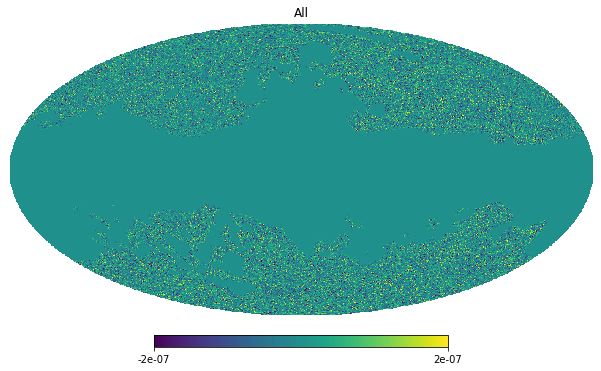

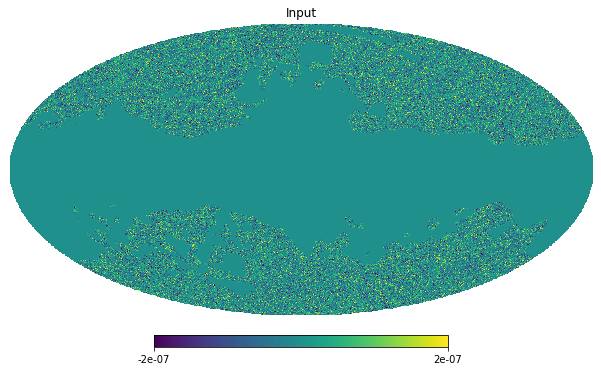

In [38]:
#lonra, latra = [-80,80], [-70,70]
#for ctype, lab in [('klb','LiteBIRD'),('ext',r'CIB+$\delta_g$'),('all','All'),('inp','Input')]:
for ctype, lab in [('all','All'),('inp','Input')]:
    #hp.cartview(kmap[ctype],lonra=lonra,latra=latra,min=-3e-7,max=3e-7,title=lab)
    hp.mollview(mask['lbfull']*bmap[ctype],min=-2e-7,max=2e-7,title=lab)